In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import tensorflow as tf
import os
import random

In [2]:
def transform(image):
    image_yuv = cv.cvtColor(image, cv.COLOR_RGB2YUV)
    image_yuv[:, :, 0] = cv.equalizeHist(image_yuv[:, :, 0])
    image = cv.cvtColor(image_yuv, cv.COLOR_YUV2RGB)
    kernels = []
    for theta in np.arange(0, np.pi, np.pi / 8):
        kernel = cv.getGaborKernel((17,17), 4.0, theta, 10.0, 0.5, 0, ktype=cv.CV_32F)
        kernels.append(kernel)
    
    filtered_images = []
    for kernel in kernels:
        filtered_img = cv.filter2D(image, cv.CV_8UC3, kernel)
        filtered_images.append(filtered_img)
    filtered_images_stacked = np.concatenate(filtered_images, axis=-1)
    
    return filtered_images_stacked

In [3]:
root = './train'
buckets = {}
images = []
labels = []

for img_name in os.listdir(root):
    class_img = img_name.split('_')[0]
    if class_img == 'nv': continue
    img = cv.imread(os.path.join(root,img_name))
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (224,224))
    img = transform(img)
    if class_img in buckets: buckets[class_img]+=1
    else: buckets[class_img] = 0
    images.append(img)
    labels.append(class_img)

error: OpenCV(4.8.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.simd_helpers.hpp:94: error: (-2:Unspecified error) in function 'cv::impl::(anonymous namespace)::CvtHelper<cv::impl::(anonymous namespace)::Set<3, 4, -1>, cv::impl::(anonymous namespace)::Set<3, -1, -1>, cv::impl::(anonymous namespace)::Set<0, 2, 5>, cv::impl::(anonymous namespace)::NONE>::CvtHelper(cv::InputArray, cv::OutputArray, int) [VScn = cv::impl::(anonymous namespace)::Set<3, 4, -1>, VDcn = cv::impl::(anonymous namespace)::Set<3, -1, -1>, VDepth = cv::impl::(anonymous namespace)::Set<0, 2, 5>, sizePolicy = cv::impl::(anonymous namespace)::NONE]'
> Unsupported depth of input image:
>     'VDepth::contains(depth)'
> where
>     'depth' is 6 (CV_64F)


In [ ]:
# i = random.randint(0,len(images))
# plt.figure(figsize=(8,4))
# plt.subplot(1,2,1)
# plt.imshow(images[i])
# plt.title(labels[i])
# i = random.randint(0,len(images))
# plt.subplot(1,2,2)
# plt.imshow(images[i])
# plt.title(labels[i])
# plt.tight_layout()
# plt.show()

In [ ]:
print(buckets)

{'bkl': 1098, 'mel': 1112, 'df': 114, 'bcc': 513, 'akiec': 326, 'vasc': 141}


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)
images = np.array(images)
labels = np.array(labels)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [ ]:
# plt.subplot(1,2,1)
# i = random.randint(0,len(X_train))
# plt.imshow(X_train[i])
# plt.title(f'{y_train[i]}, train')
# i = random.randint(0,len(X_test))
# plt.subplot(1,2,2)
# plt.imshow(X_test[i])
# plt.title(f'{y_test[i]}, test')

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 24)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dense(6, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      6944      
                                                                 
 batch_normalization (Batch  (None, 222, 222, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 batch_normalization_1 (Bat  (None, 109, 109, 64)      256       
 chNormalization)                                                
                                                        

In [ ]:
# callbacks = [ tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5), 
#             tf.keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{val_loss:.2f}.h5') ]

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
83/83 [==============================] - 180s 2s/step - loss: 4.9185 - accuracy: 0.3399 - val_loss: 1.6416 - val_accuracy: 0.3172
Epoch 2/10
83/83 [==============================] - 129s 2s/step - loss: 1.4225 - accuracy: 0.4347 - val_loss: 1.6132 - val_accuracy: 0.3172
Epoch 3/10
83/83 [==============================] - 140s 2s/step - loss: 1.1957 - accuracy: 0.5196 - val_loss: 1.6325 - val_accuracy: 0.3701
Epoch 4/10
25/83 [========>.....................] - ETA: 1:41 - loss: 1.0160 - accuracy: 0.5838

KeyboardInterrupt: 

In [ ]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
acc = acc*100
print('Test Accuracy: %.3f' % acc)

Test Accuracy: 27.543


20/20 [==============================] - 12s 597ms/step


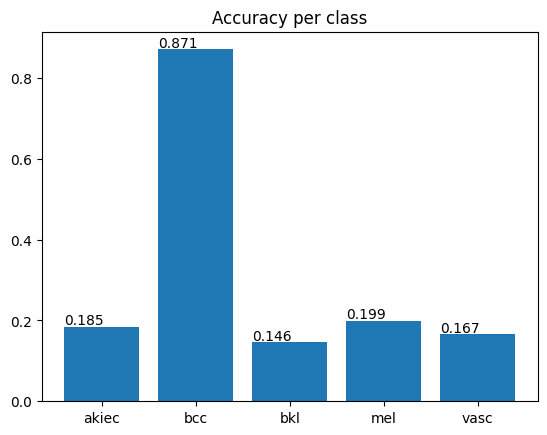

In [ ]:
y_pred = model.predict(X_test)
y_pred_label = np.argmax(y_pred, axis=1)
y_test_label = np.argmax(y_test, axis=1)
# make a bargraph of accuracy per class
from sklearn.metrics import accuracy_score
acc_per_class = []
for i in range(5):
    acc_per_class.append(accuracy_score(y_test_label[y_test_label==i], y_pred_label[y_test_label==i]))

bars  = plt.bar(le.classes_, acc_per_class)
plt.title('Accuracy per class')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x(), yval + .005, round(yval,3))
plt.show()

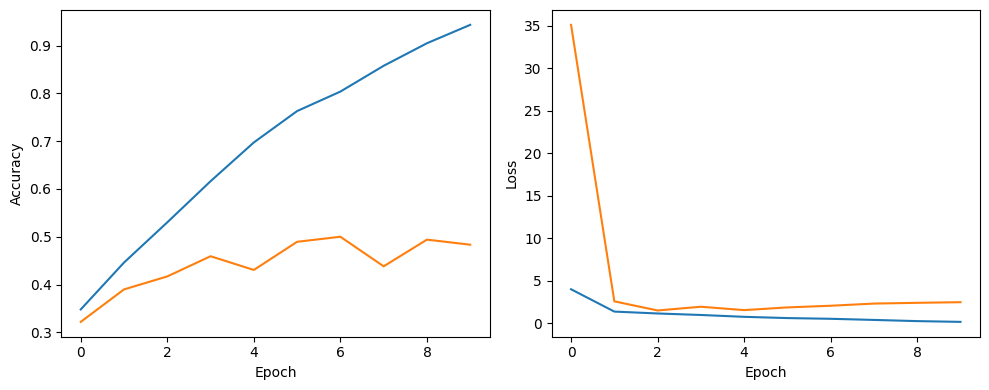

In [ ]:
model.save('model_contrast.keras')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()